# Test 1: Basic SWB2 options and Thornthwaite-Mather water budget

## Summary of test

This test combines the most commonly used SWB2 program options and completes a model run using tabular precipitation and air temperature inputs. The output is compared to the same calculations made using a simple Python version of the same algorithms, _as well as a version of the algorithms that references the original Thornthwaite-Mather soil-moisture-retention tables._ This test provides checks on the following swb2 functionality:

1. Snowfall
2. Temperature index-based snowmelt
3. Snow storage
4. Thornthwaite-Mather soil-moisture-retention algorithm implementation as compared to tabular values
5. Hargreaves-Samani calculation for reference evapotranspiration
6. Actual evapotranspiration
7. Net infiltration

For this test, a curve number of '0' is used in the SWB run, essentially ensuring that there is never any runoff calculated in SWB. This is done to make the initial comparison to the Thornthwaite-Mather soil-moisture-retention tables easier to understand. The only active sources of water are rainfall and snowmelt; the sinks are actual evapotranspiration and net infiltration. 

The first half of this notebook may be skipped unless one is interested in the details of how the various model runs are set up. Basically, a simple SWB2 model is executed, followed by a set of Python implementations of SWB2. The results are compared in the last half of this notebook.


## Discussion

As of swb2, version 2.3.5-rc0, the comparisons of the swb2 output to the Python versions are virtually identical. Note that for the soil-moisture retention and actual evapotranspiration comparisons, there is a discrepancy between swb2 and the output of the Python version *when using the original Thornthwaite-Mather soil-moisture retention table values*. This discrepency appears to be a function of the number of significant figures that are present in the original Thornthwaite and Mather (1957) tables:

![alt text](../images/thornthwaite_mather_soil-moisture-table_example.png)

Calculating the soil-moisture-retention with the exponential relation (discussed below) retains more numerical precision and results in less round-off error. The swb2 results compare well to the soil-moisture-retention calculated with the exponential relation.

In [1]:
# high-level imports
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import subprocess

In [2]:
# define working directories for use in making a forward run of SWB2
base_dir = str(Path.cwd().parent)
python_script_dir = Path.cwd().parent / 'python'
test_dir = Path.cwd().parent / 'test__thornthwaite_mather'
logfile_dir = test_dir / 'logfiles'
test_data_dir = Path.cwd().parent / 'test_data'
tm_table_file = test_data_dir / 'Thornthwaite_soil_moisture_retention_tables__millimeters.csv'
output_dir = test_dir / 'output'
swb2_executable = str(Path.cwd().parent / 'bin' /'swb2.exe')
sys.path.append(str(python_script_dir))

from swb_cell import SWBCell
import run_management as rm

## Test setup

#### Define paths to swb2 executable and working/input data directories

#### Read in Thornthwaite-Mather soil moisture retention table

In [3]:
tm_soil_moisture_retention_df = pd.read_csv(tm_table_file)

#### Remove and replace working directories for swb2 run

In [4]:
rm.destroy_model_work_output_and_logfile_dirs(base_dir=base_dir,
                                              test_dir=test_dir,
                                              logfile_dir=logfile_dir,
                                              output_dir=output_dir)
rm.create_model_work_output_and_logfile_dirs(base_dir=base_dir,
                                             test_dir=test_dir,
                                             logfile_dir=logfile_dir,
                                             output_dir=output_dir)


#### Make a new swb2 model run for a single cell example

In the following step, a new swb2 model run is started using a pre-configured swb control file. The swb model contains a single cell. Daily weather data is a table of precipitation and tmax/tmin values. The test case is centered on the airport at Kenai, Alaska.

In [5]:
dry_run = False
lookup_dir_arg_text = f"--lookup_dir={str(test_data_dir)}"
weather_data_dir_arg_text = f"--weather_data_dir={str(test_data_dir)}"
output_dir_arg_text = f"--output_dir={str(output_dir)}"
logfile_dir_arg_text = f"--logfile_dir={str(logfile_dir)}"
control_file_path = str(test_data_dir / 'swb_control_file_kenai.ctl')
output_prefix = '--output_prefix=swb_kenai_'

swb_arg_text = [swb2_executable, output_dir_arg_text, lookup_dir_arg_text, weather_data_dir_arg_text, output_prefix, logfile_dir_arg_text, control_file_path]

f = open(test_dir / "stdout.txt", "w")

if not dry_run:
  with rm.cd(test_dir):
#    p = subprocess.Popen(swb_arg_text, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    p = subprocess.Popen(swb_arg_text, stdout=f, stderr=subprocess.DEVNULL)
    p.wait()

#### Read in swb2 model results

In [6]:
swb_df = pd.read_csv(Path(output_dir, 'SWB2_variable_values__Kenai_Airpt__col_1__row_1__x_150393__y_1179331.csv'))
# eliminate pesky spaces around column names
swb_df.columns = swb_df.columns.str.replace(' ', '')

#### Convert swb Imperial units to metric

In [7]:
swb_df['tminf'] = swb_df.loc[:,'tmin']
swb_df['tmaxf'] = swb_df.loc[:,'tmax']
swb_df['tmeanf'] = swb_df.loc[:,'tmean']
swb_df.loc[:,'tmin'] = (swb_df.loc[:,'tmin'] - 32) / 1.8
swb_df.loc[:,'tmax'] = (swb_df.loc[:,'tmax'] - 32) / 1.8
swb_df.loc[:,'tmean'] = (swb_df.loc[:,'tmean'] - 32) / 1.8
swb_df.loc[:,'gross_precip'] = swb_df.loc[:,'gross_precip'] * 25.4
swb_df.loc[:,'rainfall'] = swb_df.loc[:,'rainfall'] * 25.4
swb_df.loc[:,'actual_ET'] = swb_df.loc[:,'actual_ET'] * 25.4
swb_df.loc[:,'reference_ET0'] = swb_df.loc[:,'reference_ET0'] * 25.4
swb_df.loc[:,'soil_storage'] = swb_df.loc[:,'soil_storage'] * 25.4
swb_df.loc[:,'snow_storage'] = swb_df.loc[:,'snow_storage'] * 25.4
swb_df.loc[:,'snowfall'] = swb_df.loc[:,'snowfall'] * 25.4
swb_df.loc[:,'snowmelt'] = swb_df.loc[:,'snowmelt'] * 25.4
swb_df.loc[:,'net_infiltration'] = swb_df.loc[:,'net_infiltration'] * 25.4
swb_df.loc[:,'infiltration'] = swb_df.loc[:,'infiltration'] * 25.4

swb_df['date'] = pd.to_datetime(swb_df['date'])

#### Create a Python versions of a swb2 cell

Three simple Python implementations of a SWB cell are created here. The implementations differ only in the way that the soil-moisture-retention relations are implemented. The example uses data from Kenai, Alaska.

The three Thornthwaite-Mather implementations are:
1. 'tm_exp': soil moisture extraction is determined by means of a simple exponential relation,
2. 'tm_table': soil moisture extraction is determined by looking up daily retention values in the Thornthwaite-Mather soil moisture retention tables, and
3. 'tm_eqns': soil moisture extraction is determined by applying a set of equations fitted to the original Thornthwaite-Mather soil moisture retention tables.

The current method of choice in the compiled SWB2 code uses a simple exponential relation. Previous versions of the code used table values directly (SWB1), or used fitted equations to approximate the table values (SWB2).

In [8]:
# swb2 still uses Imperial units (inches and feet); the Python code expects metric units (mm and m).
# The example control file we're using for swb2 specifies 3.6 inches/foot for the available water capacity.
# 3.6 inches per foot equals 300 mm/m. The rooting depth is specified in the swb2 lookup table as 1.6404 feet, 
# or 1.6404 ft / 3.2808 ft/m = 0.5 m
mycell_exp = SWBCell(latitude=60.57154, available_water_capacity=300., rooting_depth=1.0, calculation_method='tm_exp')

mycell_tab = SWBCell(latitude=60.57154, available_water_capacity=300., rooting_depth=1.0, calculation_method='tm_table',
                    thornthwaite_mather_df=tm_soil_moisture_retention_df)

mycell_eqns = SWBCell(latitude=60.57154, available_water_capacity=300., rooting_depth=1.0, calculation_method='tm_eqns')

#### Initialize Python versions of swb

In [9]:
mycell_exp.init_swb_cell()
mycell_tab.init_swb_cell()
mycell_eqns.init_swb_cell()

#### Iterate and solve the water budget in Python over the date range contained in the swb2 output file
There are three Python versions. The first uses an exponential decay function to approximate the Thornthwaite-Mather (TM) soil moisture retention tables. The second version actually looks up the TM table values directly; the third method uses a set of fitted equations to interpolate between table values.

In [10]:
for index, row in swb_df.iterrows():
    year = int(row['year'])
    month = int(row['month'])
    day = int(row['day'])
    # exponential decay to approximate TM
    mycell_exp.calc_cell_water_budget(year, month, day,
                                      row['tmin'],row['tmax'],row['tmean'],row['gross_precip'])
    mycell_exp.variables_todict()
    # TM table values read in directly
    mycell_tab.calc_cell_water_budget(year, month, day,
                                      row['tmin'],row['tmax'],row['tmean'],row['gross_precip'])
    mycell_tab.variables_todict()
    # TM tables approximated by fitted equations to interpolate between table values
    mycell_eqns.calc_cell_water_budget(year, month, day,
                                       row['tmin'],row['tmax'],row['tmean'],row['gross_precip'])
    mycell_eqns.variables_todict()
    print(f"making calculation for {year}-{month}-{day}")

making calculation for 1967-1-1
making calculation for 1967-1-2
making calculation for 1967-1-3
making calculation for 1967-1-4
making calculation for 1967-1-5
making calculation for 1967-1-6
making calculation for 1967-1-7
making calculation for 1967-1-8
making calculation for 1967-1-9
making calculation for 1967-1-10
making calculation for 1967-1-11
making calculation for 1967-1-12
making calculation for 1967-1-13
making calculation for 1967-1-14
making calculation for 1967-1-15
making calculation for 1967-1-16
making calculation for 1967-1-17
making calculation for 1967-1-18
making calculation for 1967-1-19
making calculation for 1967-1-20
making calculation for 1967-1-21
making calculation for 1967-1-22
making calculation for 1967-1-23
making calculation for 1967-1-24
making calculation for 1967-1-25
making calculation for 1967-1-26
making calculation for 1967-1-27
making calculation for 1967-1-28
making calculation for 1967-1-29
making calculation for 1967-1-30
making calculation 

#### Convert the output dictionaries to dataframes

In [11]:
mycell_exp.convert_dict_to_df()
py_exp_df = mycell_exp.output_df.copy()
py_exp_df.loc[:,'date'] = pd.to_datetime(py_exp_df['date'])

In [12]:
mycell_tab.convert_dict_to_df()
py_tab_df = mycell_tab.output_df.copy()
py_tab_df.loc[:,'date'] = pd.to_datetime(py_tab_df['date'])

In [13]:
mycell_eqns.convert_dict_to_df()
py_eqns_df = mycell_eqns.output_df.copy()
py_eqns_df.loc[:,'date'] = pd.to_datetime(py_eqns_df['date'])

#### Merge the swb and python model outputs into a single dataframe

In [14]:
df = pd.merge(left=py_exp_df, right=py_tab_df, on='date', suffixes=('_e','_t'))
df = pd.merge(left=df, right=py_eqns_df, on='date', suffixes=(None,'_q'))
df = pd.merge(left=df, right=swb_df, on='date', suffixes=(None, '_s'))
#display(df.columns.to_list())

In [15]:
# estimate 'P minus PET' for swb
df['p_minus_pet'] = (df['snowmelt'] + df['rainfall'] - df['crop_etc']) * 25.4

## Test comparisons

In [16]:
my_subset = df[(df['date'] > "1967-01-01") & (df['date'] < "1968-12-31")]
#my_subset[['date','tmin','tmax','tmean','tminf','tmaxf','tmeanf','gross_precip','soil_storage_s','soil_storage_p',
#           'infiltration', 'p_minus_pet_s','p_minus_pet',
#           'reference_ET0','pet','actual_ET','aet']]
df = my_subset

### SNOWFALL

SWB2 uses the same empirical relations as were used in Dripps (2003) and Dripps and Bradbury (2007) to partition gross precipitation into 'rainfall' and 'snowfall', on the basis of daily minimum, mean, and maximum air temperatures.


$$
snow: T_{mean} - \frac{1}{3}(T_{max} - T_{min}) \leq 32
$$
$$
rain: T_{mean} - \frac{1}{3}(T_{max} - T_{min}) > 32
$$

where:

$T_{mean}$ is the mean daily air temperature, in degrees Fahrenheit,

$T_{max}$ is the maximum daily air temperature, in degrees Fahrenheit,

$T_{mean}$ is the minimum daily air temperature, in degrees Fahrenheit.


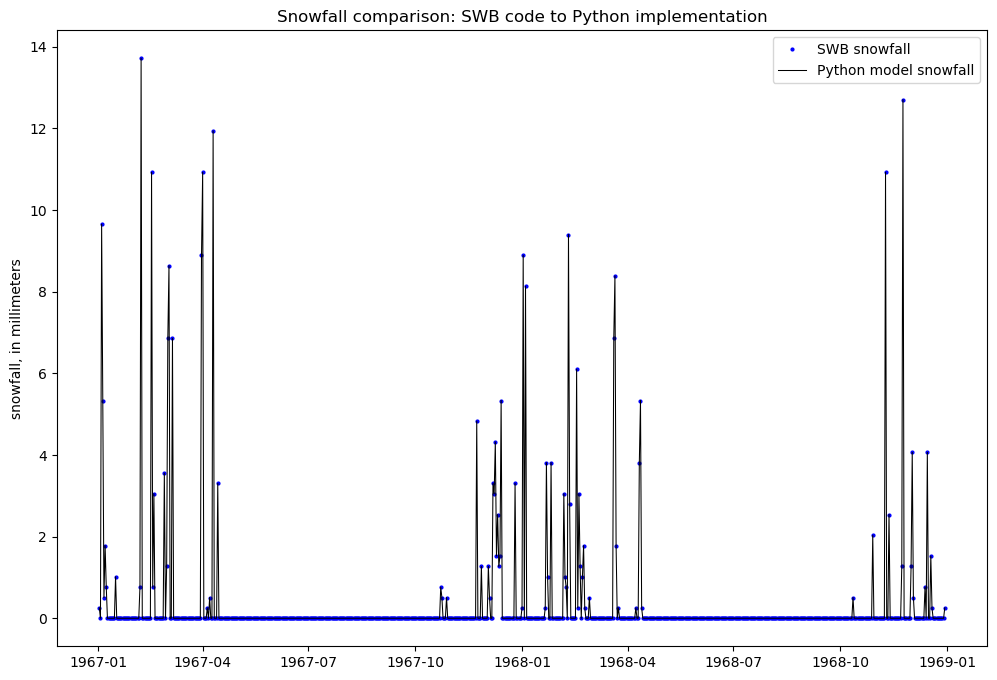

In [17]:
fig, ax = plt.subplots(1,1,figsize=(12, 8),sharex=False)
ax.plot(df['date'], df['snowfall'], marker='.', linestyle=' ', color='blue', markersize=4, label='SWB snowfall')
ax.plot(df['date'], df['snowfall_e'], marker=' ', linestyle='-', 
        color='black', linewidth=0.75, label='Python model snowfall')
ax.set_ylabel('snowfall, in millimeters')
ax.set_title('Snowfall comparison: SWB code to Python implementation')
ax.legend()

### SNOWMELT

SWB2 uses the same empirical relations as were used in Dripps (2003) and Dripps and Bradbury (2007) to estimate the potential snowmelt from accumulated snowpack on a given day. Actual snowmelt is limited by the amount of moisture stored in the snow storage reservoir.


$$
potential\, snowmelt = 1.5 \cdot (T_{max}), \, T_{max} > 0
$$

where:

$potential\, snowmelt$ is in millimeters, and

$T_{max}$ is the maximum daily air temperature, in degrees Celsius.

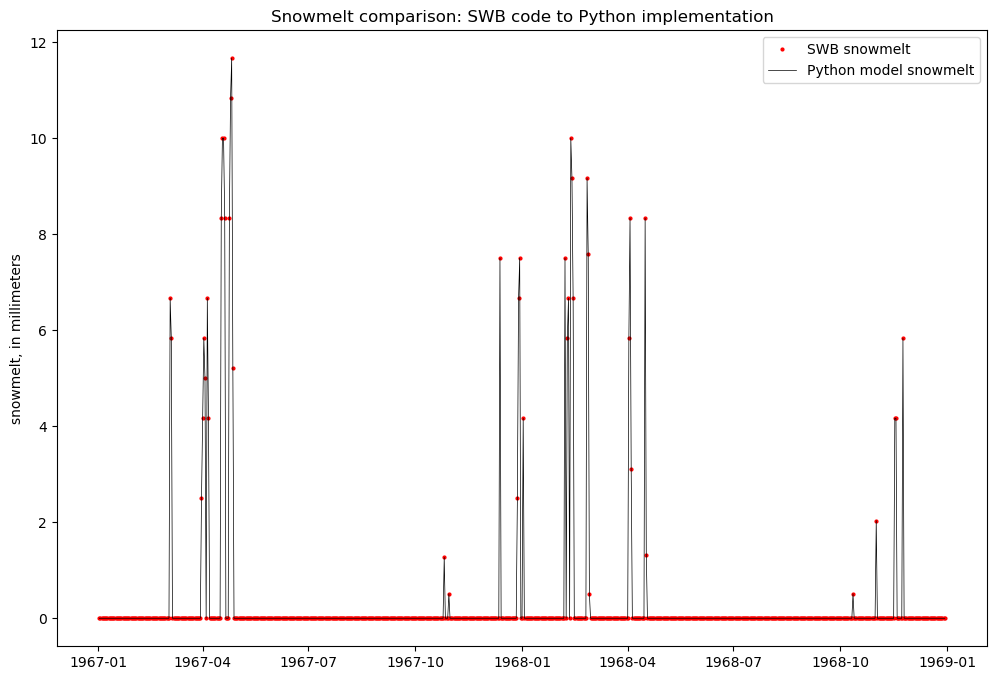

In [18]:
fig, ax = plt.subplots(1,1,figsize=(12, 8),sharex=False)
ax.plot(df['date'], df['snowmelt'], marker='.', linestyle=' ', color='red', markersize=4, label='SWB snowmelt')
ax.plot(df['date'], df['snowmelt_e'], marker=' ', linestyle='-', 
        color='black', linewidth=0.5, label='Python model snowmelt')
ax.set_ylabel('snowmelt, in millimeters')
ax.set_title('Snowmelt comparison: SWB code to Python implementation')
ax.legend()

### SNOW STORAGE

Snow storage evolves over the course of a run, with the snowfall and snowmelt calculated as noted above. If the snowfall and snowmelt components are consistent between the SWB code and the Python code, the snow storage evolution over time should be consistent as well.

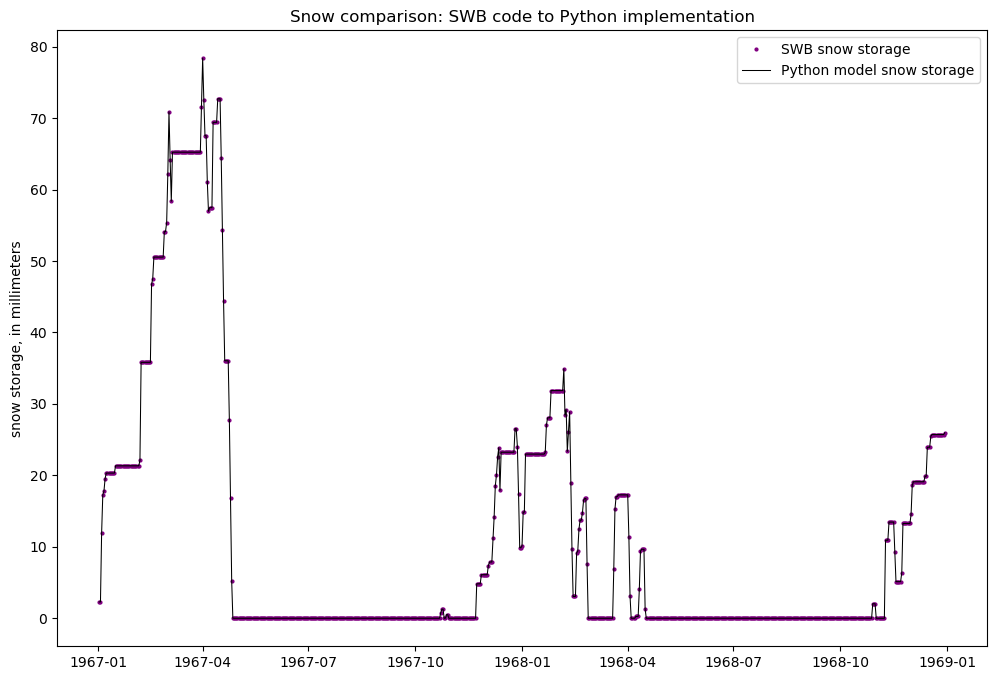

In [19]:
fig, ax = plt.subplots(1,1,figsize=(12, 8),sharex=False)
ax.plot(df['date'], df['snow_storage'], marker='.', linestyle=' ', color='purple', markersize=4, label='SWB snow storage')
ax.plot(df['date'], df['snow_storage_e'], marker=' ', linestyle='-', 
        color='black', linewidth=0.75, label='Python model snow storage')
ax.set_ylabel('snow storage, in millimeters')
ax.set_title('Snow comparison: SWB code to Python implementation')
ax.legend()

### SOIL STORAGE / SOIL-MOISTURE RETENTION

The first versions of the SWB code included extensive routines to read in and interpolate the tables of soil-moisture-retention data included in the appendixes of Thornthwaite and Mather (1957). Making daily calculations with the Thornthwaite-Mather tables involves consulting the soil-moisture retention tables for each days' worth of calculations. When precipitation is less than the potential or reference ET, the tables are consulted to first provide an updated value for the accumulated potential water loss, and then to calculate an updated soil moisture value. After working with the tables for some time, however, it became clear that the values are simply tabulated values calculated from an exponential relation relating the current days' soil moisture to the previous days' soil moisture (Alley, 1984): 

$$
S_i = S_{i-1} \,e^\frac{-(PE_i - P_i)}{\phi}
$$

where:

$S_i$ is the soil moisture on day $i$, in millimeters

$S_{i-1}$ is the soil moisture on day $i-1$, in millimeters

$PE$ is the potential evapotranspiration, in millimeters

$P$ is the daily precipitation amount, in millimeters, and

$\phi$ is the size of the soil moisture reservoir, in millimeters.

Note in the figure below (top plot) that __using the table values directly results in some minor departure from the calculations made with the exponential or fitted equation versions__. This is likely because the tabular values are all truncated to 1mm of resolution with respect to the current values of moisture retained in the soil. There is a bit of roundoff error involved when using the tabular values directly. The issue with roundoff is lessened when equations fitted to the tabular values are used rather than the table values directly (bottom plot). 

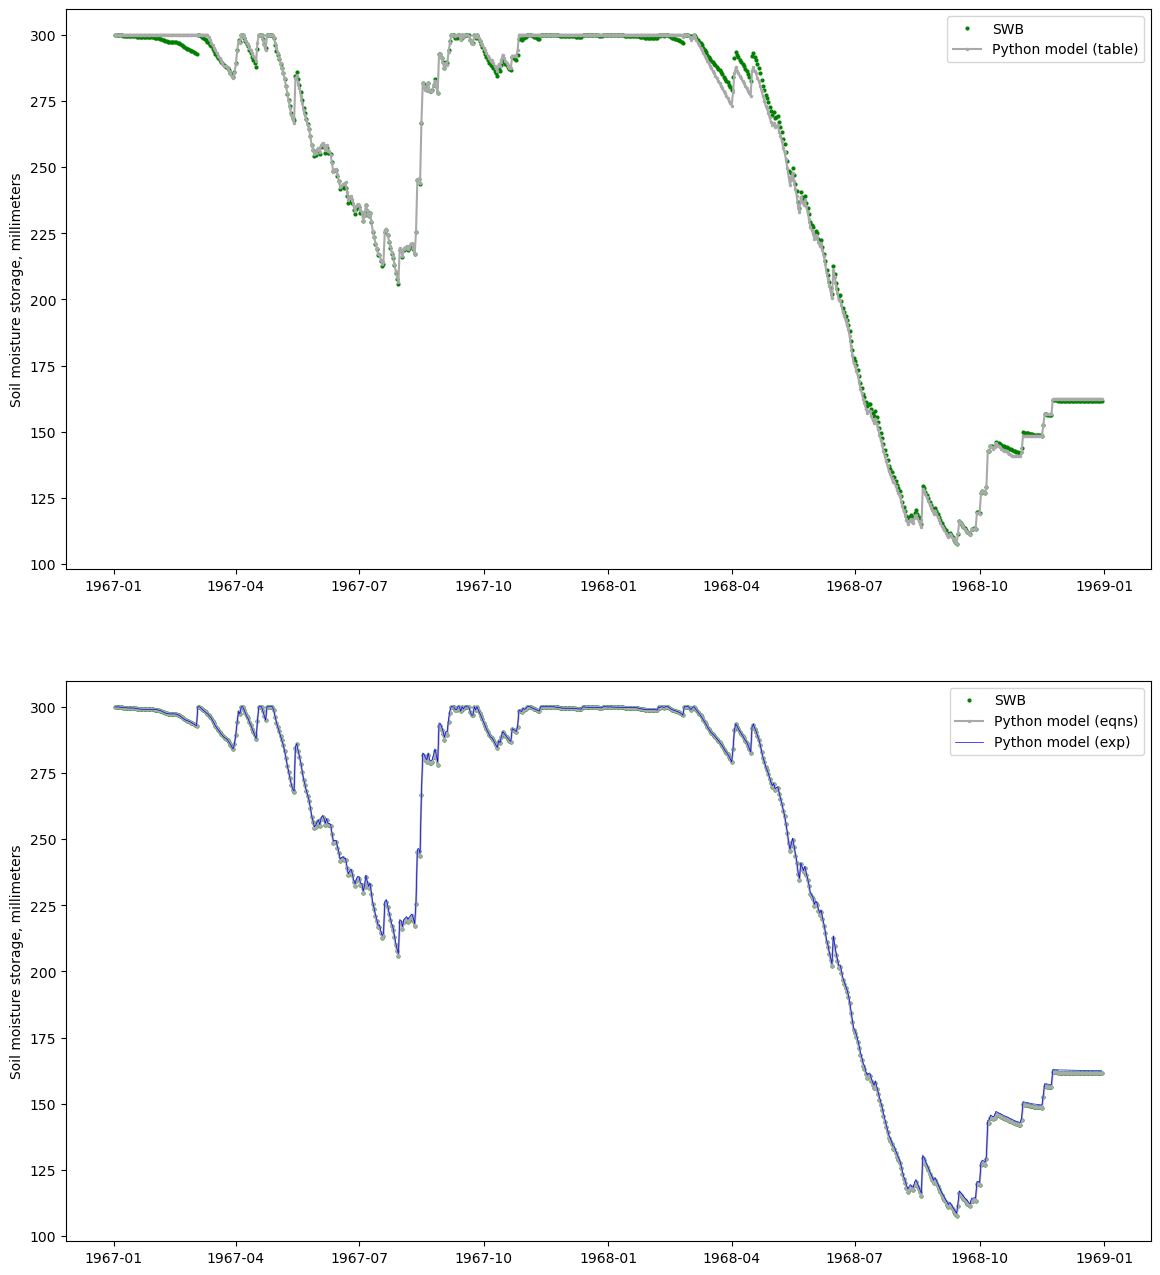

In [20]:
fig = plt.figure(figsize=(14, 16))

ax = fig.add_subplot(2,1,1)
ax.plot(df['date'], df['soil_storage'], marker='.', linestyle=' ', color='green', markersize=4, label='SWB')
ax.plot(df['date'], df['soil_storage_t'], marker='.', linestyle='-', color='darkgray', markersize=3, label='Python model (table)')
#ax.plot(df['date'], df['soil_storage_e'], marker=' ', linestyle='-', 
#        color='blue', linewidth=0.5, label='Python model (exp)')
ax.set_ylabel('Soil moisture storage, millimeters')
ax.legend()

ax = fig.add_subplot(2,1,2)
ax.plot(df['date'], df['soil_storage'], marker='.', linestyle=' ', color='green', markersize=4, label='SWB')
ax.plot(df['date'], df['soil_storage'], marker='.', linestyle='-', color='darkgray', markersize=3, label='Python model (eqns)')
ax.plot(df['date'], df['soil_storage_e'], marker=' ', linestyle='-', 
        color='blue', linewidth=0.5, label='Python model (exp)')
ax.set_ylabel('Soil moisture storage, millimeters')
ax.legend()


### REFERENCE EVAPOTRANSPIRATION

This test case makes use of the Hargreaves-Samani method for estimating reference evapotranspiration from only minimum and maximum daily air temperatures. There is a cascade of calculations that go into calculating reference ET using Hargreaves and Samani. First, the code makes a number of calculations relating to the potential amount of solar radiation, including the relative earth-sun distance, solar declination, and sunset angle given the current day of the year within the simulation. The difference between $T_{max}$ and $T_{min}$ is used as a proxy for the amount of potential solar radiation that reaches the land surface, and directly influences the total reference evapotranspiration calculated on a particular day.

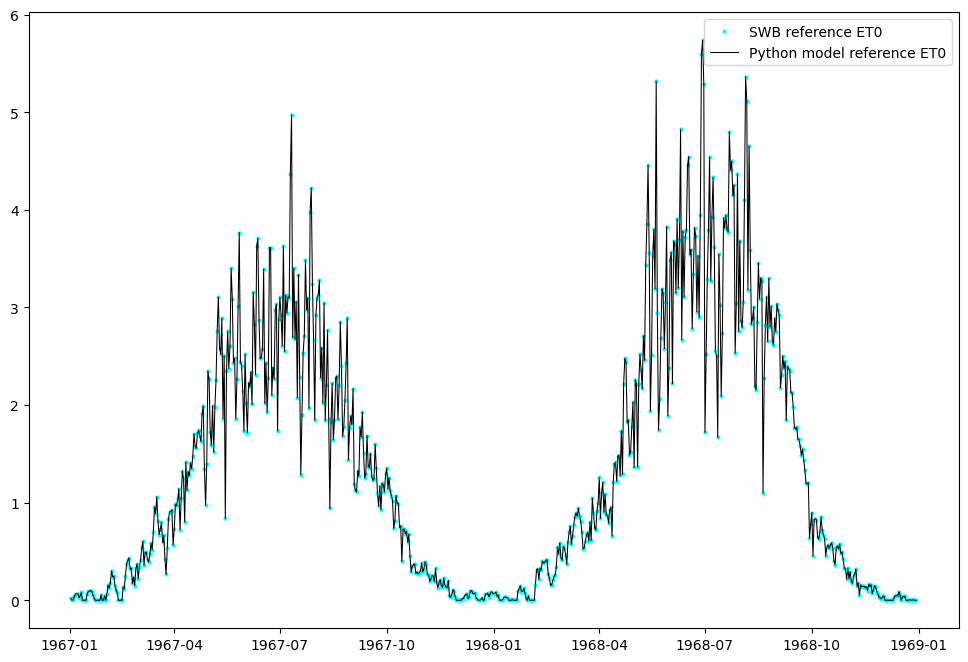

In [21]:
fig, ax = plt.subplots(1,1,figsize=(12, 8),sharex=False)
ax.plot(df['date'], df['reference_ET0'], marker='.', linestyle=' ', color='cyan', markersize=4, label='SWB reference ET0')
ax.plot(df['date'], df['pet_e'], marker=' ', linestyle='-', 
        color='black', linewidth=0.75, label='Python model reference ET0')
ax.legend()

### ACTUAL EVAPOTRANSPIRATION

Actual evapotranspiration tracks the amount of moisture that can be extracted from the soil on a given day. There is a clear discrepancy between the Python calculated actual evapotranspiration based on the Thornthwaite and Mather (1957) table values (shown in grey) as compared to the exponential soil-moisture-retention relation (shown in green).

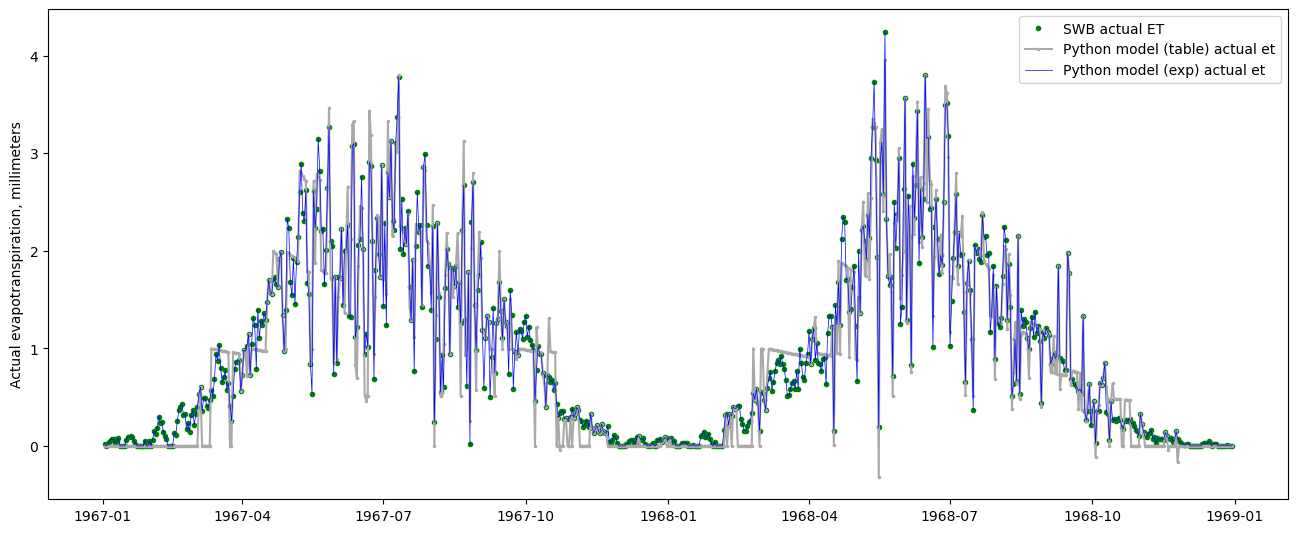

In [24]:
fig = plt.figure(figsize=(16, 14))
ax = fig.add_subplot(2,1,1)
ax.plot(df['date'], df['actual_ET'], marker='.', linestyle=' ', color='green', markersize=6, label='SWB actual ET')
ax.plot(df['date'], df['aet_t'], marker='.', linestyle='-', color='darkgray', markersize=3, label='Python model (table) actual et')
ax.plot(df['date'], df['aet_e'], marker=' ', linestyle='-', 
        color='blue', linewidth=0.5, label='Python model (exp) actual et')
ax.set_ylabel('Actual evapotranspiration, millimeters')
ax.legend()

### NET INFILTRATION

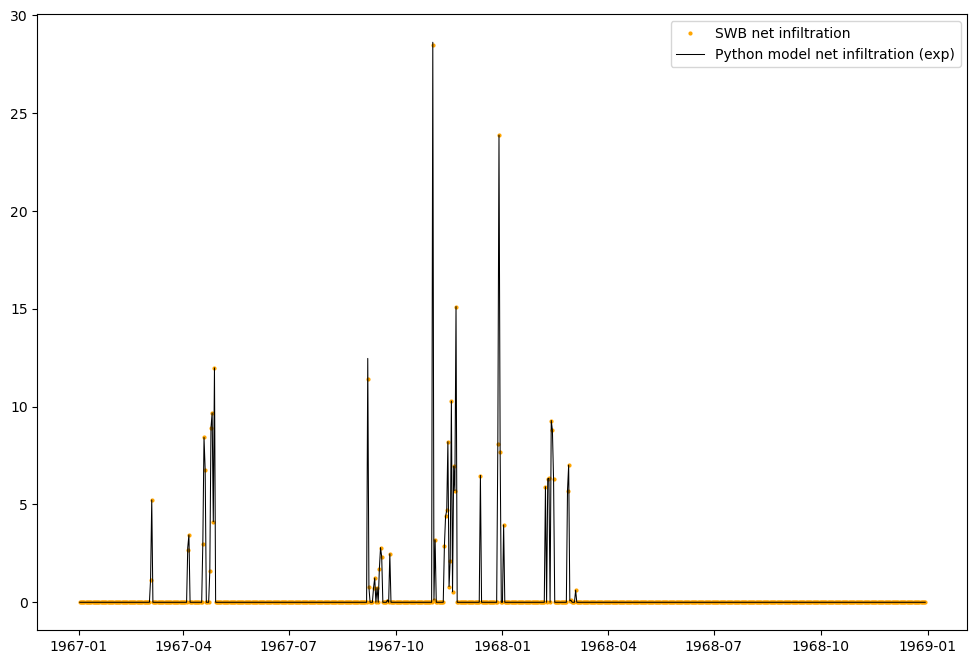

In [23]:
fig, ax = plt.subplots(1,1,figsize=(12, 8),sharex=False)
ax.plot(df['date'], df['net_infiltration'], marker='.', linestyle=' ', color='orange', markersize=4, label='SWB net infiltration')
#ax.plot(df['date'], df['net_infiltration_t'], marker=' ', linestyle='-', 
#        color='brown', linewidth=0.75, label='Python model net infiltration (table)')
ax.plot(df['date'], df['net_infiltration_e'], marker=' ', linestyle='-', 
        color='black', linewidth=0.75, label='Python model net infiltration (exp)')
ax.legend()

## Summary

This test demonstrates that the SWB2 Thornthwaite-Mather soil moisture accounting is consistent with the Python reimplementation of the same algorithms. Key aspects verified:

1. **Soil moisture retention tables** — SWB2's exponential functions produce the similar soil moisture values as the published Thornthwaite-Mather (1957) tables. Discrepancies are likely due to the limited reporting precision of the original table values.
2. **Accumulated potential water loss (APWL)** — The running deficit accumulation matches between SWB2 and Python for both wet and dry periods.
3. **Actual evapotranspiration** — Daily AET computed from the soil moisture retention relation is consistent across implementations.
4. **Net infiltration (recharge)** — Excess soil moisture above field capacity is correctly identified as recharge.
5. **Snow partitioning and melt** — Precipitation is correctly split into rainfall and snowfall based on temperature, and snowmelt is computed using a temperature-index method.
6. **Hargreaves reference ET** — The reference ET0 computation from daily temperature data matches between SWB2 and Python.